# Data Modeling: Air Quality Inequality
**Model:** Random Forest Classifier  
**Goal:** Predict whether a county has high vs. low AQI based on socioeconomic and demographic features.  
**Why Random Forest?** Random Forest answer our main question directly through feature importances because if median income ranks highly, it supports the idea that lower-income counties face worse air quality.

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded.')

Libraries loaded.


## 1. Load Data

In [2]:
conn = sqlite3.connect('aqi_project.db')
df = pd.read_sql("SELECT * FROM analysis_data", conn)
conn.close()

print(f'Shape: {df.shape}')
print(df.dtypes)
df.head()

Shape: (549, 15)
fips                     object
total_pop                 int64
median_age              float64
pop_65_and_over         float64
median_income           float64
incidence_rate          float64
days_aqi                  int64
unhealthy_days            int64
very_unhealthy_days       int64
hazardous_days            int64
median_aqi                int64
pct_over_65             float64
unhealthy_days_total      int64
pct_unhealthy_air       float64
income_tier              object
dtype: object


,fips,total_pop,median_age,pop_65_and_over,median_income,incidence_rate,days_aqi,unhealthy_days,very_unhealthy_days,hazardous_days,median_aqi,pct_over_65,unhealthy_days_total,pct_unhealthy_air,income_tier
0,01003,261608,43.8,59367.0,82501.0,58.2,241,0,0,0,42,0.226931,0,0.0,Med-High
1,01049,73122,37.6,13288.0,52763.0,52.7,243,0,0,0,42,0.181724,0,0.0,Low
2,01051,91042,40.8,16027.0,81846.0,67.7,177,0,0,0,32,0.176040,0,0.0,Med-High
3,01055,103207,41.3,20914.0,57959.0,69.4,241,0,0,0,45,0.202641,0,0.0,Low
4,01073,664744,37.7,116099.0,69363.0,51.5,182,0,0,0,53,0.174652,0,0.0,Med-Low


## 2. Feature Engineering & Target Creation

In [ ]:
# Find the AQI column to use as target
aqi_col = next((c for c in df.columns if 'median_aqi' in c.lower() or 'aqi' in c.lower()), None)
print(f'AQI column detected: {aqi_col}')

# All numeric columns except the AQI target and ID columns
drop_patterns = ['county', 'state', 'fips', 'name', 'year', 'id']
feature_cols = [
    c for c in df.columns
    if c != aqi_col
    and df[c].dtype in ['float64', 'int64']
    and not any(p in c.lower() for p in drop_patterns)
]

print(f'Features ({len(feature_cols)}):', feature_cols)

AQI column detected: days_aqi
Features (11): ['total_pop', 'median_age', 'pop_65_and_over', 'median_income', 'unhealthy_days', 'very_unhealthy_days', 'hazardous_days', 'median_aqi', 'pct_over_65', 'unhealthy_days_total', 'pct_unhealthy_air']


In [4]:
# Binary target: 1 = High AQI (above median = worse air quality), 0 = Low AQI
threshold = df[aqi_col].median()
df['high_aqi'] = (df[aqi_col] > threshold).astype(int)

print(f'AQI median threshold: {threshold:.1f}')
print(df['high_aqi'].value_counts().rename({0: 'Low AQI', 1: 'High AQI'}))

AQI median threshold: 243.0
high_aqi
Low AQI     292
High AQI    257
Name: count, dtype: int64


In [5]:
model_df = df[feature_cols + [aqi_col, 'high_aqi']].dropna()
X = model_df[feature_cols]
y = model_df['high_aqi']

print(f'Modeling dataset: {X.shape[0]} counties, {X.shape[1]} features')

Modeling dataset: 549 counties, 11 features


## 3. Train/Test Split & Model Training

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {len(X_train)} | Test: {len(X_test)}')

rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
print('Model trained.')

Train: 439 | Test: 110
Model trained.


## 4. Evaluation

In [7]:
# 5-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X, y, cv=cv, scoring='f1')
print(f'5-Fold CV F1: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')

# Test set report
y_pred = rf.predict(X_test)
print('\nTest Set Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Low AQI', 'High AQI']))

5-Fold CV F1: 0.613 ± 0.037

Test Set Classification Report:
              precision    recall  f1-score   support

     Low AQI       0.61      0.69      0.65        59
    High AQI       0.58      0.49      0.53        51

    accuracy                           0.60       110
   macro avg       0.60      0.59      0.59       110
weighted avg       0.60      0.60      0.60       110



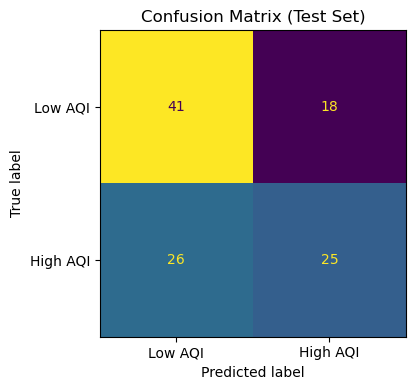

In [8]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=['Low AQI', 'High AQI']).plot(ax=ax, colorbar=False)
ax.set_title('Confusion Matrix (Test Set)')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Feature Importance

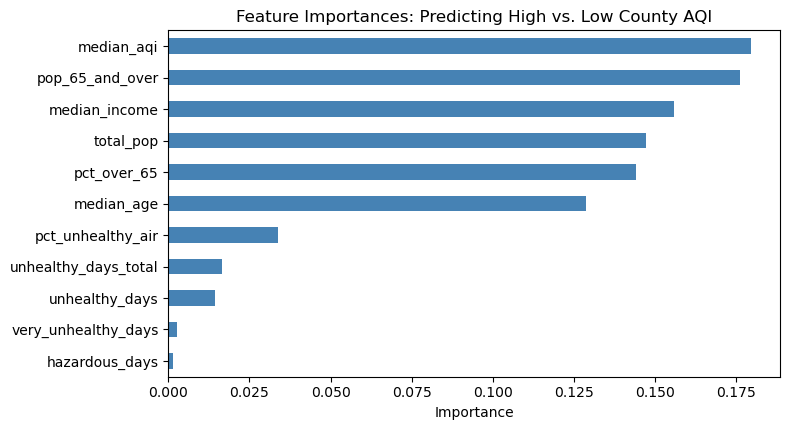

In [9]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, max(4, len(importances) * 0.4)))
importances.plot(kind='barh', ax=ax, color='steelblue')
ax.invert_yaxis()
ax.set_xlabel('Importance')
ax.set_title('Feature Importances: Predicting High vs. Low County AQI')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Error Analysis

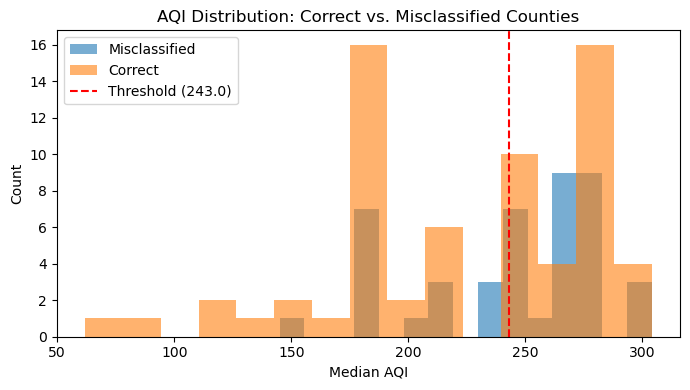

In [10]:
test_results = X_test.copy()
test_results['actual'] = y_test.values
test_results['predicted'] = y_pred
test_results['correct'] = (test_results['actual'] == test_results['predicted'])
test_results['median_aqi'] = model_df.loc[X_test.index, aqi_col].values

# AQI distribution: correct vs misclassified
fig, ax = plt.subplots(figsize=(7, 4))
for correct, grp in test_results.groupby('correct'):
    ax.hist(grp['median_aqi'], bins=15, alpha=0.6, label='Correct' if correct else 'Misclassified')
ax.axvline(threshold, color='red', linestyle='--', label=f'Threshold ({threshold:.1f})')
ax.set_xlabel('Median AQI')
ax.set_ylabel('Count')
ax.set_title('AQI Distribution: Correct vs. Misclassified Counties')
ax.legend()
plt.tight_layout()
plt.savefig('error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Save Outputs

In [11]:
# Predictions
test_results.to_csv('predictions.csv', index=False)

# Feature importances
importances.reset_index().rename(columns={'index': 'feature', 0: 'importance'}).to_csv('feature_importance.csv', index=False)

# CV scores
pd.DataFrame({'fold': range(1, 6), 'f1_score': cv_scores}).to_csv('cv_scores.csv', index=False)

# Error summary
test_results.groupby('correct')[feature_cols].mean().round(3).to_csv('error_analysis_summary.csv')

print('Saved: predictions.csv, feature_importance.csv, cv_scores.csv, error_analysis_summary.csv')

Saved: predictions.csv, feature_importance.csv, cv_scores.csv, error_analysis_summary.csv


## 8. Results Interpretation

**Model:** Random Forest Classifier (100 trees)

**Evaluation:** Stratified 80/20 train-test split + 5-fold cross-validation  
**Primary metric:** F1-score

**Interpreting the results:**  
- **Feature importances:** Features near the top are the strongest socioeconomic predictors of high AQI which key evidence for the environmental justice argument.
- **Confusion matrix:** False negatives (high-AQI counties predicted as low) are the most costly error in a policy context meaning those are communities being missed.
- **Error analysis plot:** Most misclassifications will cluster near the AQI threshold as counties right at the median are expected to be harder to classify.